In [124]:
import pandas as pd
import matplotlib.pyplot as plt

# Evaluation on Non-Metazoan and Unreviewed Data Sets
both of these have an intact signal peptide.

## Non-Metazoan
(keyword:KW-0800) AND (reviewed:true) AND (date_created:[* TO 2026-03-03]) NOT (taxonomy_id:33208)

```bash
uv run toxfam predict non_metazoan \
  --model-dir model/model_output/combined_run \
  --toxicity-only \
  -o benchmark/non_metazoan/predict/combined_toxicity.tsv
   Resolved dataset 'non_metazoan' -> non_metazoan.tsv
```

In [125]:
non_metazoan_df = pd.read_csv("../benchmark/non_metazoan/predict/combined_toxicity.tsv", sep='\t')
non_metazoan_df.head()

,identifier,p_toxic,predicted_toxic
0,A0A0H2US87,0.011873,False
1,A0A0H3AIG7,0.118866,False
2,A0A0H3NK84,0.001348,False
3,A0A1S4NYE3,0.028274,False
4,A0A218N034,0.000010,False


In [126]:
non_metazoan_df["predicted_toxic"].value_counts()

predicted_toxic
False    548
True     264
Name: count, dtype: int64

### Hypothesis: can the combined model flag toxicity in *non-metazoan* proteins?

All 812 non-metazoan entries are reviewed **KW-0800 toxins** — i.e. every one is a true positive, so the only thing measurable here is **recall / sensitivity** (what fraction the model flags as toxic). Specificity / false-positive rate cannot be measured without a non-metazoan *non-toxin* set.

Two reasons to expect it to struggle:
- The combined model's taxonomy branch is trained on **50 metazoan taxa** — **all 812** non-metazoan organisms fall outside them, so every taxonomy vector is all-zero (dead branch).
- The model has never seen non-metazoan sequences in training (out-of-distribution).

If the model *could* indicate toxicity here, most of these known toxins should score a high P(toxic). The plot below tests that.

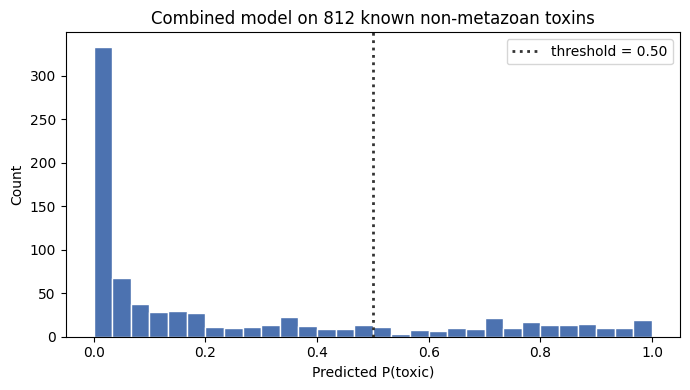

median P(toxic) = 0.07 — most true toxins are scored non-toxic
recall (thr=0.50) = 22%


In [127]:
# P(toxic) distribution for the 812 known non-metazoan toxins
import matplotlib.pyplot as plt

p = non_metazoan_df["p_toxic"]
recall_050 = (p >= 0.5).mean()       # fraction flagged toxic at 0.5

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(p, bins=30, color="#4C72B0", edgecolor="white")

ax.axvline(0.5, color="#333333", ls=":", lw=2,
            label=f"threshold = 0.50")
ax.set_xlabel("Predicted P(toxic)")
ax.set_ylabel("Count")
ax.set_title(f"Combined model on {len(p)} known non-metazoan toxins")
ax.legend()
fig.tight_layout()
plt.show()

print(f"median P(toxic) = {p.median():.2f} — most true toxins are scored non-toxic")
print(f"recall (thr=0.50) = {recall_050:.0%}")

### Takeaway

The combined model **cannot yet reliably indicate toxicity in non-metazoan proteins**: median P(toxic) is ~0.07 and it flags only ~22% (thr 0.5) of *known* non-metazoan toxins. The taxonomy branch is inactive out-of-kingdom (all 812 organisms fall outside the 50 metazoan taxa), and the sequences are out-of-distribution.

This motivates future work rather than an application claim: **adding non-metazoan toxins (and non-toxins) to training, fine-tuning / domain adaptation, and expanding the taxonomy vocabulary beyond metazoa**.

## Unreviewed
(keyword:KW-0800) AND (reviewed:false) AND (taxonomy_id:33208) AND (fragment:false) AND (date_created:[* TO 2026-06-10])

```bash
uv run toxfam predict unreviewed \
  --model-dir model/model_output/combined_run \
  -o benchmark/unreviewed/predict/combined.tsv
```

In [128]:
unreviewed_df = pd.read_csv("../benchmark/unreviewed/predict/combined.tsv", sep='\t')
unreviewed_input = pd.read_csv("../data/evaluation/unreviewed/unreviewed.tsv", sep='\t')

print("Input columns: ",unreviewed_input.columns)
unreviewed_df.head()

Input columns:  Index(['Entry', 'Organism', 'Protein families', 'Sequence', 'Organism (ID)'], dtype='object')


,identifier,pred_1,conf_1,pred_2,conf_2,pred_3,conf_3,p_toxic,predicted_toxic
0,A0A4Y2G8R1,nontox,0.998813,Peptidase S1 family,0.000351,Venom metalloproteinase (M12B) family,0.000324,0.001187,False
1,A0A670IWD1,nontox,0.841922,other,0.042451,Insulin family,0.018022,0.158078,False
2,A0A670J0E7,nontox,0.556936,Venom metalloproteinase (M12B) family,0.414533,Disintegrin family,0.009423,0.443064,True
3,A0A670K065,other,0.939281,nontox,0.055751,Limacoditoxin family,0.000599,0.944249,True
4,A0A670K3I7,other,0.949134,nontox,0.046272,Limacoditoxin family,0.000560,0.953728,True


In [129]:
# add unreviewed input "Protein families" column as "Uniprot Assignments" right after the identifier column, based on "Entry"
unreviewed_df.insert(1, "Uniprot Assignments", unreviewed_df["identifier"].map(unreviewed_input.set_index("Entry")["Protein families"]))
unreviewed_df.head()

,identifier,Uniprot Assignments,pred_1,conf_1,pred_2,conf_2,pred_3,conf_3,p_toxic,predicted_toxic
0,A0A4Y2G8R1,NOTCH family,nontox,0.998813,Peptidase S1 family,0.000351,Venom metalloproteinase (M12B) family,0.000324,0.001187,False
1,A0A670IWD1,Endothelin/sarafotoxin family,nontox,0.841922,other,0.042451,Insulin family,0.018022,0.158078,False
2,A0A670J0E7,NaN,nontox,0.556936,Venom metalloproteinase (M12B) family,0.414533,Disintegrin family,0.009423,0.443064,True
3,A0A670K065,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.939281,nontox,0.055751,Limacoditoxin family,0.000599,0.944249,True
4,A0A670K3I7,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.949134,nontox,0.046272,Limacoditoxin family,0.000560,0.953728,True


### Family-annotation suggestions on the unreviewed set

This set is from **TrEMBL**, so its family labels are automatically assigned and unreliable — it is **not** an evaluation benchmark. We use it instead to show the model can *propose* family annotations: three ranked candidates (`pred_1..3`) for every protein.

- For entries **without** a UniProt family, the model fills the gap with 3 ranked suggestions.
- For entries **with** a family, we check whether the model's top-3 reproduces it — corroborating the label or offering ranked alternatives.

To compare fairly, the UniProt labels are **collapsed exactly like preprocessing**: `normalize_protein_families` (conotoxin fixes + regex family consolidation, from `src/toxfam/data/normalization.py`), then any family outside the model's 38 trained classes (`class_indices.json`) → `other`. The agreement plot then uses entries whose collapsed label is a specific family (i.e. not the `other` catch-all).

In [130]:
import json

VOCAB = set(json.load(open("../model/model_output/combined_run/class_indices.json")).values())
print(f"In-vocabulary classes ({len(VOCAB)}):")
for _fam in sorted(VOCAB):
    print("  •", _fam)


In-vocabulary classes (38):
  • Actinoporin family
  • Bradykinin-related peptide family
  • CRISP family
  • Calycin superfamily
  • Cationic peptide family
  • Cnidaria small cysteine-rich protein (SCRiP) family
  • Conotoxin family
  • Disintegrin family
  • FARP (FMRFamide related peptide) family
  • Flavin monoamine oxidase family
  • Formicidae venom family
  • Insulin family
  • Limacoditoxin family
  • Long (3 C-C) scorpion toxin superfamily
  • Long (4 C-C) scorpion toxin superfamily
  • Long chain scorpion toxin family
  • MCD family
  • Natriuretic, Bradykinin potentiating peptide family
  • Neurotoxin family
  • Non-disulfide-bridged peptide (NDBP) superfamily
  • PBP/GOBP family
  • PDGF/VEGF growth factor family
  • Peptidase S1 family
  • Phospholipase family
  • Scoloptoxin family
  • Sea anemone sodium channel inhibitory toxin family
  • Sea anemone type 1 potassium channel toxin family
  • Sea anemone type 3 (BDS) potassium channel toxin family
  • Short scorpion toxi

In [131]:
# Collapse UniProt family labels the same way preprocessing does, so they are comparable
# to the model's 38-class vocabulary (see src/toxfam/data/normalization.py):
#   1. normalize_protein_families(): conotoxin fixes + regex family consolidation
#      (min_count=1 disables the dataset-relative frequency collapse — we use the fixed model vocab instead)
#   2. map any family outside the model's classes -> "other"; keep unannotated entries as NaN
from toxfam.data.normalization import normalize_protein_families

_raw = unreviewed_df["Uniprot Assignments"]
_norm = normalize_protein_families(
    _raw.rename("Protein families").to_frame(), column="Protein families", min_count=1
)["Protein families"]
_norm = _norm.where(_raw.notna(), other=pd.NA)                       # keep unannotated as NaN
unreviewed_df["fam_normalized"] = _norm                              # normalized name, before vocab collapse
unreviewed_df["fam_collapsed"] = _norm.where(_norm.isin(VOCAB) | _norm.isna(), other="other")

unreviewed_df["fam_collapsed"].value_counts(dropna=False).head(10)

fam_collapsed
<NA>                               9562
other                              6789
Conotoxin family                   3061
Peptidase S1 family                1569
Cationic peptide family             478
Flavin monoamine oxidase family     408
Calycin superfamily                 217
Phospholipase family                176
Snaclec family                      160
CRISP family                        159
Name: count, dtype: int64

126 distinct UniProt families collapsed to 'other'  (6,789 proteins)


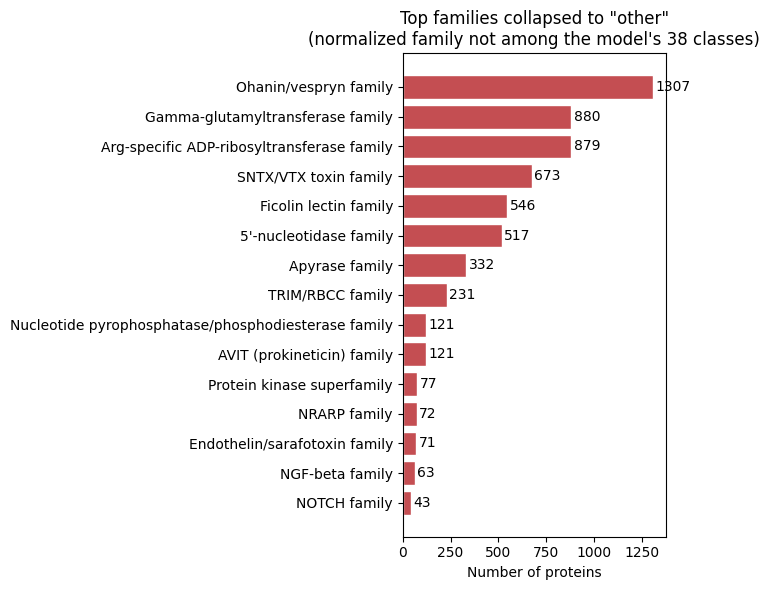

fam_normalized
Ohanin/vespryn family                                  1307
Gamma-glutamyltransferase family                        880
Arg-specific ADP-ribosyltransferase family              879
SNTX/VTX toxin family                                   673
Ficolin lectin family                                   546
5'-nucleotidase family                                  517
Apyrase family                                          332
TRIM/RBCC family                                        231
Nucleotide pyrophosphatase/phosphodiesterase family     121
AVIT (prokineticin) family                              121
Protein kinase superfamily                               77
NRARP family                                             72
Endothelin/sarafotoxin family                            71
NGF-beta family                                          63
NOTCH family                                             43
ANKLE2 family                                            43
DHHC palmitoyltransferase

In [132]:
# Which families fell into the "other" abyss? (normalized UniProt family outside the model's 38 classes)
abyss = unreviewed_df.loc[unreviewed_df["fam_collapsed"] == "other", "fam_normalized"].value_counts()
print(f"{abyss.size} distinct UniProt families collapsed to 'other'  ({int(abyss.sum()):,} proteins)")

top = abyss.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color="#C44E52", edgecolor="white")
for y, v in enumerate(top.values):
    ax.text(v + max(top.values) * 0.01, y, str(int(v)), va="center")
ax.set_xlabel("Number of proteins")
ax.set_title('Top families collapsed to "other"\n(normalized family not among the model\'s 38 classes)')
fig.tight_layout()
plt.show()

abyss.head(20)

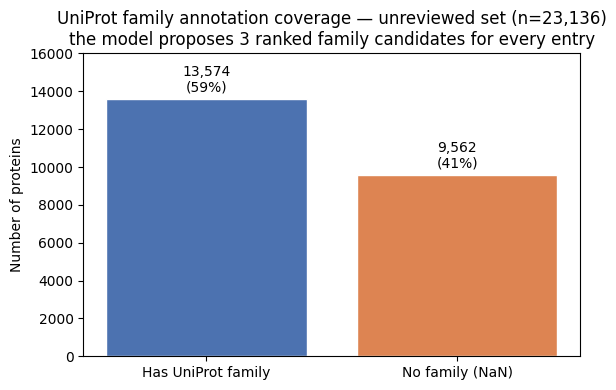

In [133]:
# Annotation coverage of the unreviewed set: how many carry a UniProt family vs none

FAMILY_COL = "Uniprot Assignments"
n = len(unreviewed_df)
n_nan = unreviewed_df[FAMILY_COL].isna().sum()
n_ann = n - n_nan

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Has UniProt family", "No family (NaN)"], [n_ann, n_nan],
              color=["#4C72B0", "#DD8452"], edgecolor="white")
for b, v in zip(bars, [n_ann, n_nan]):
    ax.text(b.get_x() + b.get_width() / 2, v + n * 0.01,
            f"{v:,}\n({v / n:.0%})", ha="center", va="bottom")
ax.set_ylim(0, max(n_ann, n_nan) * 1.18)
ax.set_ylabel("Number of proteins")
ax.set_title(f"UniProt family annotation coverage — unreviewed set (n={n:,})\n"
             "the model proposes 3 ranked family candidates for every entry")
fig.tight_layout()
plt.show()

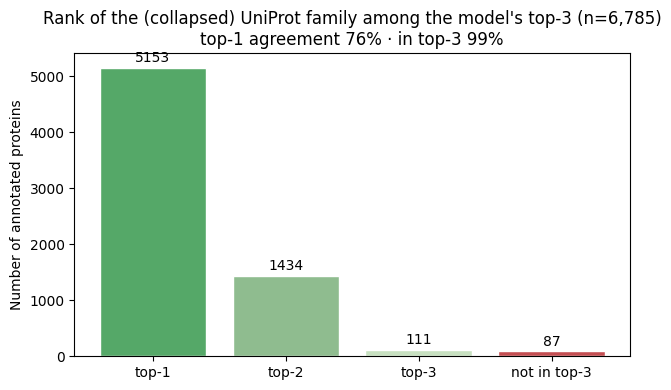

In [134]:
# Where does the (collapsed) UniProt family land in the model's top-3?
# Only entries whose collapsed label is a specific family (excludes the "other" catch-all, "nontox", and unannotated).
comparable = unreviewed_df[
    unreviewed_df["fam_collapsed"].notna()
    & ~unreviewed_df["fam_collapsed"].isin(["other", "nontox"])
].copy()

def match_rank(r):
    for i, c in enumerate(["pred_1", "pred_2", "pred_3"], 1):
        if r[c] == r["fam_collapsed"]:
            return i
    return 0  # collapsed family not in the top-3

comparable["match_rank"] = comparable.apply(match_rank, axis=1)

order, labels = [1, 2, 3, 0], ["top-1", "top-2", "top-3", "not in top-3"]
vals = [(comparable["match_rank"] == k).sum() for k in order]
top1 = vals[0] / len(comparable)
top3 = sum(vals[:3]) / len(comparable)
colors = ["#55A868", "#8FBC8F", "#C7E0C0", "#C44E52"]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.01, str(v), ha="center", va="bottom")
ax.set_ylabel("Number of annotated proteins")
ax.set_title(f"Rank of the (collapsed) UniProt family among the model's top-3 "
             f"(n={len(comparable):,})\n"
             f"top-1 agreement {top1:.0%} · in top-3 {top3:.0%}")
fig.tight_layout()
plt.show()

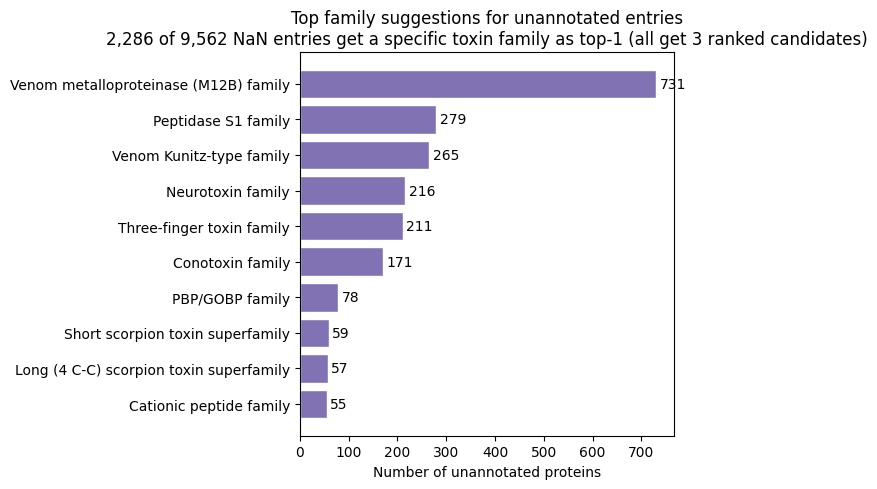

In [135]:
# Suggestions for the unannotated (NaN) entries: top toxin families proposed as pred_1

FAMILY_COL = "Uniprot Assignments"
nan = unreviewed_df[unreviewed_df[FAMILY_COL].isna()]
concrete = nan[~nan["pred_1"].isin(["nontox", "other"])]  # a specific family was proposed
top = concrete["pred_1"].value_counts().head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index, top.values, color="#8172B3", edgecolor="white")
for y, v in enumerate(top.values):
    ax.text(v + max(top.values) * 0.01, y, str(v), va="center")
ax.set_xlabel("Number of unannotated proteins")
ax.set_title(f"Top family suggestions for unannotated entries\n"
             f"{len(concrete):,} of {len(nan):,} NaN entries get a specific toxin family as top-1 "
             f"(all get 3 ranked candidates)")
fig.tight_layout()
plt.show()

### Takeaway

On the unreviewed set the combined model works as an **annotation-suggestion tool**: it emits three ranked family candidates for every protein, filling the gap for the ~41% that carry no UniProt family. On the 6,785 entries whose UniProt family (collapsed to the model's vocabulary) is a specific family, that family appears in the model's top-3 in **~99%** of cases (top-1 in **~76%**). Where the model's first pick differs, the annotated family is almost always its second suggestion, so the output either **corroborates** an existing label or **offers a ranked alternative** to review.

## Overview: family-annotation suggestions — hypothesis & limitations

The unreviewed set is from **TrEMBL**, so its labels are auto-assigned and it is **not** a formal evaluation set — but as a large real-world pool it shows the combined model works as a **family-annotation suggestion tool**:

- **Panel A — gap filling.** Every entry gets 3 ranked candidates; for the **9,562 (41%)** with *no* UniProt family, the model proposes an annotation where none exists (2,286 get a specific family as their top pick).
- **Panel B — corroboration.** For entries whose UniProt family the model can express, that family is the **top-1 pick ~76%** of the time and lands in the **top-3 ~99%** — either *confirming* the existing label or *surfacing it as a ranked alternative* to review.

**Limitations** (why this is a suggestion aid, not ground truth):
- **Families outside the model's labels** — 6,789 entries carry a UniProt family beyond the 38 classes (126 distinct families → `other`); the model cannot name these.
- **Fine-grained families** — training collapses sub-families (all conotoxin classes → `Conotoxin family`, three-finger-toxin variants → one class), so the model returns the family but not the fine-grained subtype.
- **Taxa outside the taxonomy vector** — 266 entries come from organisms not among the 50 predefined taxa, giving an all-zero taxonomy vector that weakens the combined model's taxonomy branch.

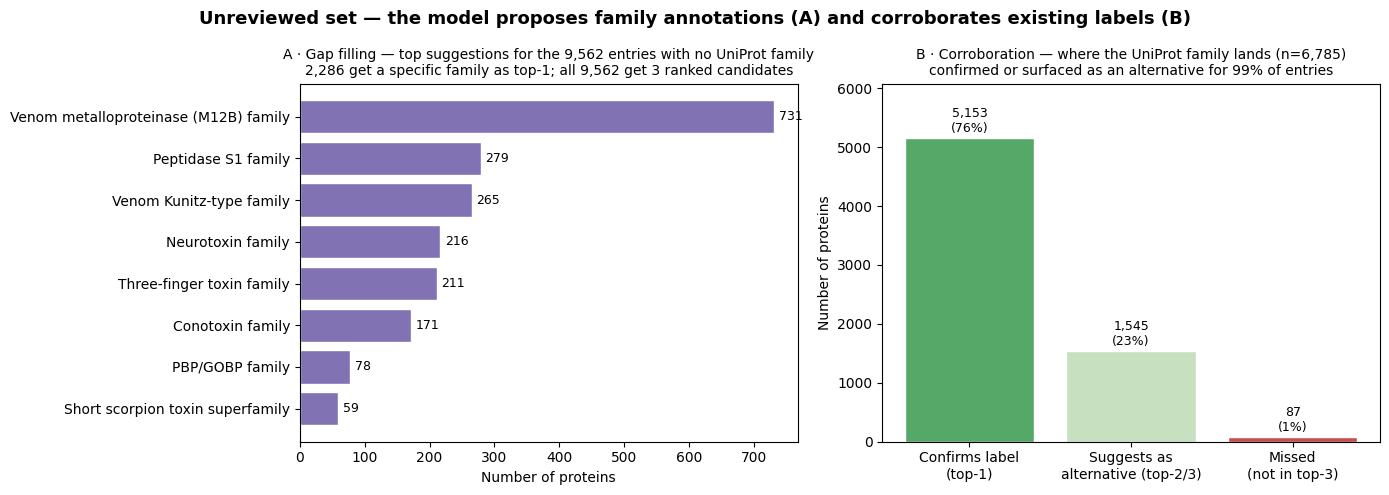

In [136]:
# ── Overview: the combined model as a family-annotation suggestion tool on the unreviewed (TrEMBL) set ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — GAP FILLING: top family suggestions for entries WITHOUT a UniProt family
nan = unreviewed_df[unreviewed_df["fam_collapsed"].isna()]
concrete = nan[~nan["pred_1"].isin(["nontox", "other"])]      # a specific family proposed as top-1
top = concrete["pred_1"].value_counts().head(8).iloc[::-1]
ax1.barh(top.index, top.values, color="#8172B3", edgecolor="white")
for y, v in enumerate(top.values):
    ax1.text(v + max(top.values) * 0.01, y, f"{v:,}", va="center", fontsize=9)
ax1.set_xlabel("Number of proteins")
ax1.set_title(f"A · Gap filling — top suggestions for the {len(nan):,} entries with no UniProt family\n"
              f"{len(concrete):,} get a specific family as top-1; all {len(nan):,} get 3 ranked candidates",
              fontsize=10)

# Panel B — CORROBORATION: for entries WITH a family (collapsed to model vocab), does the top-3 reproduce it?
comparable = unreviewed_df[
    unreviewed_df["fam_collapsed"].notna() & ~unreviewed_df["fam_collapsed"].isin(["other", "nontox"])
].copy()
comparable["mr"] = comparable.apply(
    lambda r: next((i for i, c in enumerate(["pred_1", "pred_2", "pred_3"], 1) if r[c] == r["fam_collapsed"]), 0),
    axis=1,
)
confirms = int((comparable["mr"] == 1).sum())
alt = int(comparable["mr"].isin([2, 3]).sum())
miss = int((comparable["mr"] == 0).sum())
cats = ["Confirms label\n(top-1)", "Suggests as\nalternative (top-2/3)", "Missed\n(not in top-3)"]
counts = [confirms, alt, miss]
bars = ax2.bar(cats, counts, color=["#55A868", "#C7E0C0", "#C44E52"], edgecolor="white")
for b, v in zip(bars, counts):
    ax2.text(b.get_x() + b.get_width() / 2, v + max(counts) * 0.01,
             f"{v:,}\n({v / len(comparable):.0%})", ha="center", va="bottom", fontsize=9)
ax2.set_ylim(0, max(counts) * 1.18)
ax2.set_ylabel("Number of proteins")
ax2.set_title(f"B · Corroboration — where the UniProt family lands (n={len(comparable):,})\n"
              f"confirmed or surfaced as an alternative for {(confirms + alt) / len(comparable):.0%} of entries",
              fontsize=10)

fig.suptitle("Unreviewed set — the model proposes family annotations (A) and corroborates existing labels (B)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()